<a href="https://colab.research.google.com/github/danielgil2026/c-digoprueba/blob/main/Copia_de_Exploracion_Activos_YahooFinance_Pandas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Explorando activos financieros con Python y pandas
## Análisis exploratorio de activos de un portafolio

En este laboratorio aprenderás a obtener datos financieros, explorarlos con **pandas**, transformarlos y encontrar información útil para analizar activos.

> **Idea clave:** primero observamos los datos, después calculamos y finalmente interpretamos.


## 🧭 Ruta de aprendizaje

**1. Conectar con los datos** → Yahoo Finance y tickers  
**2. Conocer la información** → DataFrame y estructura  
**3. Mirar antes de calcular** → exploración inicial  
**4. Seguir el comportamiento** → precios y gráficos  
**5. Medir los cambios** → rendimientos  
**6. Describir lo encontrado** → estadísticas  
**7. Comparar para comprender** → varios activos  
**8. Buscar relaciones** → correlación  
**9. Tu análisis** → misión individual


# 1. 🔌 Conectar con los datos

### ¿De dónde obtenemos la información?

Yahoo Finance contiene información histórica de diferentes activos financieros. Para acceder a ella desde Python utilizaremos **yfinance**.

Un **ticker** es el código utilizado para identificar un activo. Por ejemplo: `AAPL`, `MSFT`, `AMZN` o `GOOGL`.


In [29]:
!pip -q install yfinance

In [30]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Nuestro primer activo

Comencemos con Apple. Más adelante cambiaremos el ticker para trabajar con los activos asignados.

In [31]:
ticker = "AAPL"

datos = yf.download(
    ticker,
    start="2020-01-01",
    end="2025-01-01",
    auto_adjust=False
)

datos.head()

[*********************100%***********************]  1 of 1 completed


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,,
2020-01-02,72.271545,75.087502,75.150002,73.797501,74.059998,135480400
2020-01-03,71.568901,74.357498,75.144997,74.125000,74.287498,146322800
2020-01-06,72.139214,74.949997,74.989998,73.187500,73.447502,118387200
2020-01-07,71.799927,74.597504,75.224998,74.370003,74.959999,108872000
2020-01-08,72.954910,75.797501,76.110001,74.290001,74.290001,132079200


# 2. 🧩 Conocer la información

Lo que acabamos de obtener es un **DataFrame de pandas**: una estructura de datos organizada en filas y columnas.

Antes de analizar, necesitamos saber qué contiene la tabla y cómo está organizada.


In [32]:
datos.head()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,,
2020-01-02,72.271545,75.087502,75.150002,73.797501,74.059998,135480400
2020-01-03,71.568901,74.357498,75.144997,74.125000,74.287498,146322800
2020-01-06,72.139214,74.949997,74.989998,73.187500,73.447502,118387200
2020-01-07,71.799927,74.597504,75.224998,74.370003,74.959999,108872000
2020-01-08,72.954910,75.797501,76.110001,74.290001,74.290001,132079200


In [33]:
datos.tail()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,,
2024-12-24,256.339783,258.200012,258.209991,255.289993,255.490005,23234700
2024-12-26,257.153778,259.019989,260.100006,257.630005,258.190002,27237100
2024-12-27,253.748550,255.589996,258.700012,253.059998,257.829987,42355300
2024-12-30,250.382950,252.199997,253.500000,250.750000,252.229996,35557500
2024-12-31,248.615784,250.419998,253.279999,249.429993,252.440002,39480700


In [34]:
datos.shape

(1258, 6)

In [35]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1258 entries, 2020-01-02 to 2024-12-31
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Adj Close, AAPL)  1258 non-null   float64
 1   (Close, AAPL)      1258 non-null   float64
 2   (High, AAPL)       1258 non-null   float64
 3   (Low, AAPL)        1258 non-null   float64
 4   (Open, AAPL)       1258 non-null   float64
 5   (Volume, AAPL)     1258 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 68.8 KB


### 🧠 Piensa

- ¿Qué representa una fila?
- ¿Qué representa una columna?
- ¿Qué información contiene el índice?
- ¿Cuántas observaciones tenemos?

Estas preguntas forman parte del **análisis exploratorio de datos**.

# 3. 🔎 Mirar antes de calcular

Una exploración inicial nos ayuda a detectar características, diferencias o posibles problemas antes de comenzar a realizar cálculos.

In [36]:
datos.describe()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
count,1258.000000,1258.000000,1258.000000,1258.000000,1258.000000,1.258000e+03
mean,151.247343,154.108800,155.660348,152.379123,153.951948,9.057103e+07
std,41.815934,41.520877,41.654310,41.305929,41.466618,5.324438e+07
min,54.117027,56.092499,57.125000,53.152500,57.020000,2.323470e+07
25%,126.170294,129.624996,130.755005,127.505001,129.017506,5.546825e+07
50%,149.839378,152.805000,154.570000,150.825005,152.575005,7.628335e+07
75%,175.750446,178.850006,180.160000,177.115005,178.500004,1.077425e+08
max,257.153778,259.019989,260.100006,257.630005,258.190002,4.265100e+08


In [37]:
datos.isna().sum()

,,0
Price,Ticker,
Adj Close,AAPL,0
Close,AAPL,0
High,AAPL,0
Low,AAPL,0
Open,AAPL,0
Volume,AAPL,0


### 🧠 Interpreta

No basta con ejecutar `describe()`. Observa los resultados y piensa: ¿qué nos permite conocer cada medida sobre los datos?

# 4. 📈 Seguir el comportamiento

Comencemos observando el precio de cierre. Una gráfica puede ayudarnos a identificar tendencias y cambios que serían difíciles de observar en una tabla.

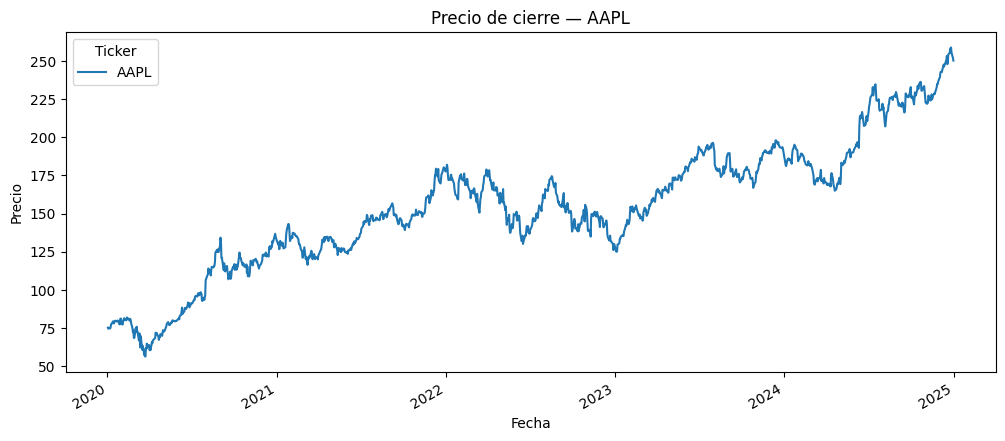

In [38]:
cierre = datos["Close"]

cierre.plot(figsize=(12, 5))
plt.title(f"Precio de cierre — {ticker}")
plt.xlabel("Fecha")
plt.ylabel("Precio")
plt.show()

### 👀 Observa

Describe brevemente lo que encuentras:

- ¿Se observan períodos de crecimiento o disminución?
- ¿Hay cambios especialmente fuertes?
- ¿El comportamiento parece estable durante todo el período?


# 5. 🔄 Medir los cambios

Comparar solamente precios puede ser insuficiente porque los activos pueden comenzar con valores muy diferentes.

Una alternativa es estudiar los **rendimientos**, que expresan el cambio de una observación respecto a la anterior.


### Cálculo de Rendimientos Financieros

Existen dos formas principales de calcular los rendimientos financieros: discretos y logarítmicos.

#### 1. Rendimientos Discretos (o Simples)

Los rendimientos discretos representan el cambio porcentual en el precio de un activo entre dos períodos consecutivos. Son intuitivos y fáciles de interpretar, ya que reflejan directamente la ganancia o pérdida en relación con el precio inicial. Son adecuados para el cálculo de rendimientos de un solo período.

La fórmula para el rendimiento discreto $R_t$ en el período $t$ es:

$$\Large R_t = \frac{P_t - P_{t-1}}{P_{t-1}} = \frac{P_t}{P_{t-1}} - 1$$

Donde:
*   $P_t$ es el precio del activo en el tiempo $t$.
*   $P_{t-1}$ es el precio del activo en el tiempo $t-1$.

### Ejemplo de Cálculo de Rendimientos

Consideremos los siguientes precios:
*   Precio Anterior ($P_{t-1}$): **100**
*   Precio Actual ($P_t$): **110**

#### 1. Cálculo del Rendimiento Discreto

Utilizando la fórmula:

$$\Large R_t = \frac{P_t - P_{t-1}}{P_{t-1}} = \frac{110 - 100}{100} = \frac{10}{100} = 0.10$$

El rendimiento discreto es **0.10** o **10%**.


In [39]:
rendimiento = cierre.pct_change()
rendimiento.head()

Ticker,AAPL
Date,
2020-01-02,NaN
2020-01-03,-0.009722
2020-01-06,0.007968
2020-01-07,-0.004703
2020-01-08,0.016086


El primer valor aparece como `NaN` porque no existe una observación anterior con la cual compararlo.


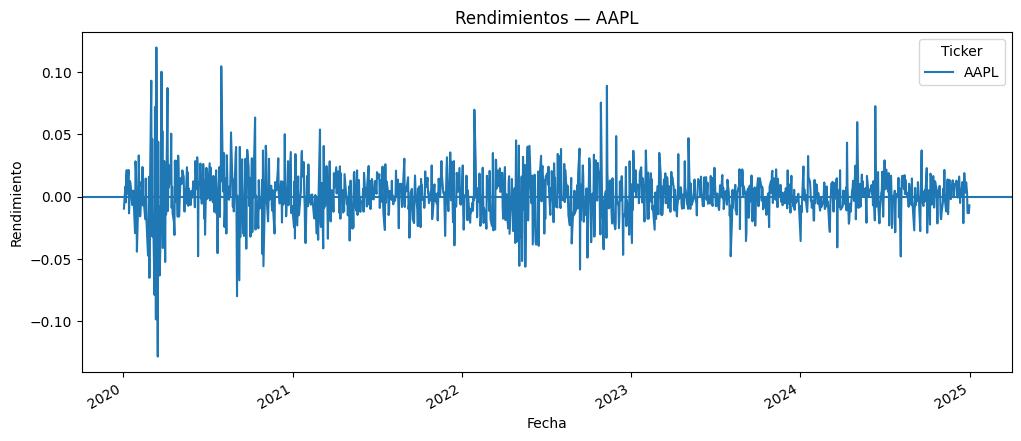

In [40]:
rendimiento.plot(figsize=(12, 5))

plt.axhline(0)
plt.title(f"Rendimientos — {ticker}")
plt.xlabel("Fecha")
plt.ylabel("Rendimiento")
plt.show()

# 6. 📐 Describir lo encontrado

Ahora podemos utilizar las estadísticas descriptivas para conocer mejor la distribución de los rendimientos.

In [41]:
rendimiento.describe()

Ticker,AAPL
count,1257.000000
mean,0.001157
std,0.019957
min,-0.128647
25%,-0.008425
50%,0.001172
75%,0.011989
max,0.119808


### Interpretación de las Estadísticas Descriptivas de Rendimientos

Al analizar la tabla de estadísticas descriptivas para los rendimientos, observamos lo siguiente:

*   **Promedio (Mean):** El promedio de los rendimientos es cercano a cero (aproximadamente 0.1157%). Esto sugiere que, a lo largo del periodo analizado, el rendimiento diario promedio del activo ha sido muy bajo, lo cual es común en series de rendimientos diarios que no muestran una tendencia marcada a largo plazo.

*   **Desviación Estándar (Std):** La desviación estándar es de aproximadamente 1.99%. Esta medida nos indica la dispersión o volatilidad de los rendimientos diarios. Un valor del 2% diario significa que, en promedio, los rendimientos suelen desviarse en un 2% (ya sea al alza o a la baja) de la media. En el contexto financiero, una mayor desviación estándar implica una mayor volatilidad y, por ende, un mayor riesgo.

*   **Mínimo (Min):** El rendimiento mínimo observado es de aproximadamente -12.86%. Esto representa la mayor pérdida porcentual experimentada por el activo en un solo día durante el periodo. Si se hubieran invertido 100 pesos, una pérdida del 12.86% implicaría que el valor de la inversión se reduciría a 87.14 pesos en ese día.

*   **Máximo (Max):** El rendimiento máximo observado es de aproximadamente 11.98%. Esta es la mayor ganancia porcentual en un solo día. Es notable que la máxima pérdida (-12.86%) es ligeramente superior a la máxima ganancia (11.98%), lo que podría indicar una asimetría en los movimientos extremos del activo, con pérdidas más severas en ciertos días.

*   **Percentil 25% (Q1):** El primer cuartil es de -0.84%. Esto significa que el 25% de los días, el rendimiento del activo fue igual o inferior a -0.84%, lo que implica una pérdida para el 25% de las observaciones.

*   **Percentil 50% (Mediana):** La mediana (percentil 50%) es de aproximadamente 0.1172%. Esto indica que el 50% de los rendimientos fueron iguales o inferiores a este valor, y el otro 50% fueron iguales o superiores. Al ser cercano a cero y ligeramente positivo, refuerza la idea de que los rendimientos oscilan alrededor de cero.

*   **Percentil 75% (Q3):** El tercer cuartil es de 1.19%. Esto significa que el 75% de los días, el rendimiento del activo fue igual o inferior a 1.19%, o dicho de otra forma, el 25% de los días la rentabilidad fue superior a 1.19%.

**Ausencia de tendencia y oscilación alrededor de cero:** Esto es típico en las series de rendimientos de activos. A diferencia de los precios, que suelen mostrar tendencias alcistas o bajistas a largo plazo, los rendimientos diarios (o periódicos) tienden a fluctuar en torno a su promedio (que a menudo es cercano a cero). Esto indica que, en el corto plazo, los movimientos positivos y negativos se compensan, sin una dirección clara y sostenida.

**Dispersión alrededor de cero y su variabilidad (Volatilidad)**: Has identificado correctamente que la dispersión de los rendimientos alrededor de cero no es constante. Esta dispersión se mide con la desviación estándar, y en el ámbito financiero se conoce como volatilidad. Una mayor dispersión (picos más altos o valles más profundos) significa mayor volatilidad, lo que implica que el precio del activo está experimentando cambios más grandes en un corto período de tiempo. Los periodos de "alta dispersión" se correlacionan con alta volatilidad (mayor riesgo), mientras que los de "baja dispersión" indican baja volatilidad (menor riesgo).

**Rangos de máximos y mínimos (Variabilidad Extrema):** La observación de que los rendimientos máximos superan el 10% y los mínimos caen por debajo del -10% es crucial. Esto te da una idea del rango extremo de movimientos que el activo ha experimentado en un solo día. Rendimientos tan altos o tan bajos en un solo día son eventos significativos que reflejan la magnitud de los shocks o noticias que afectaron al activo en esos momentos.

# Percentiles extremos


In [42]:
print("Percentil 1:", rendimiento.quantile(0.01))
print("Percentil 5:", rendimiento.quantile(0.05))

Percentil 1: Ticker
AAPL   -0.050317
Name: 0.01, dtype: float64
Percentil 5: Ticker
AAPL   -0.030125
Name: 0.05, dtype: float64


## Interpretación de Percentiles como Pérdida Máxima Esperada (VaR)

Los percentiles 1 y 5 de los rendimientos son a menudo interpretados en el contexto de **Valor en Riesgo (VaR)**, una medida clave en finanzas para cuantificar la pérdida potencial de una inversión.

*   El **percentil 1** de aproximadamente -0.050317 (-5.03%) significa que existe un **1% de probabilidad** de que el activo experimente una pérdida de 5.03% o más de su valor en un día determinado, bajo condiciones normales de mercado. Esto se puede entender como la **máxima pérdida esperada** que el activo podría sufrir con un nivel de confianza del 99% (es decir, hay solo un 1% de posibilidades de que la pérdida real sea mayor).

*   El **percentil 5** de aproximadamente -0.030125 (-3.01%) significa que existe un **5% de probabilidad** de que el activo experimente una pérdida de 3.01% o más de su valor en un día determinado. Esto se interpreta como la **máxima pérdida esperada** con un nivel de confianza del 95% (hay un 5% de posibilidades de que la pérdida real sea mayor).

En resumen, estos valores proporcionan una estimación de las pérdidas extremas que un inversor podría enfrentar con este activo en un día, junto con la probabilidad de que ocurran.

In [43]:
print("Promedio:", rendimiento.mean())
print("Desviación estándar:", rendimiento.std())
print("Mínimo:", rendimiento.min())
print("Máximo:", rendimiento.max())

Promedio: Ticker
AAPL    0.001157
dtype: float64
Desviación estándar: Ticker
AAPL    0.019957
dtype: float64
Mínimo: Ticker
AAPL   -0.128647
dtype: float64
Máximo: Ticker
AAPL    0.119808
dtype: float64


### 🧠 Interpreta

¿Qué nos dice el promedio? ¿Qué información aporta la desviación estándar? ¿Qué representan los valores mínimo y máximo?

Recuerda: **una estadística tiene sentido cuando podemos explicar qué significa en el contexto financiero.**

# 7. ⚖️ Comparar para comprender

Ahora incorporaremos varios activos. La comparación nos permitirá observar diferencias en su comportamiento.

In [44]:
activos = ["AAPL", "MSFT", "AMZN"]

datos = yf.download(
    activos,
    start="2020-01-01",
    end="2025-01-01",
    auto_adjust=False
)

precios = datos["Close"]
precios.head()

[*********************100%***********************]  3 of 3 completed


Ticker,AAPL,AMZN,MSFT
Date,,,
2020-01-02,75.087502,94.900497,160.619995
2020-01-03,74.357498,93.748497,158.619995
2020-01-06,74.949997,95.143997,159.029999
2020-01-07,74.597504,95.343002,157.580002
2020-01-08,75.797501,94.598503,160.089996


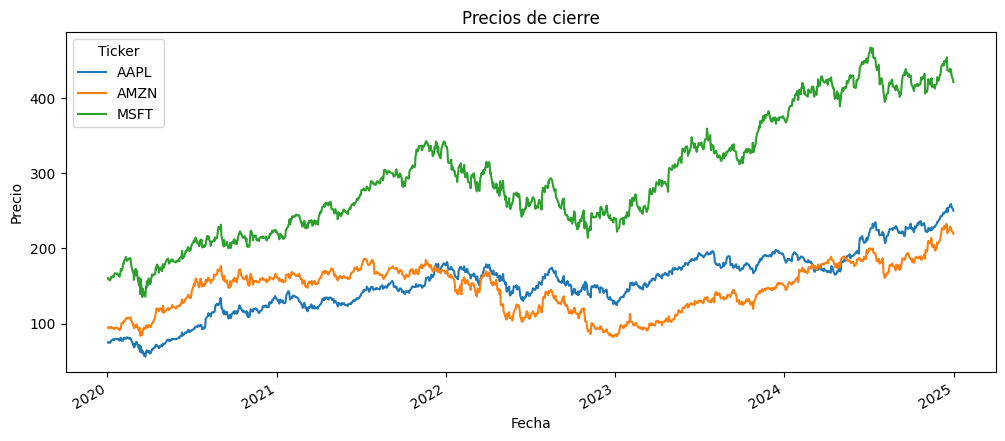

In [45]:
precios.plot(figsize=(12, 5))

plt.title("Precios de cierre")
plt.xlabel("Fecha")
plt.ylabel("Precio")
plt.show()

Los precios pueden tener escalas diferentes. Para comparar su evolución desde un mismo punto de referencia podemos construir un índice base 100.

### Normalización de Precios (Base 100)

Para comparar la evolución de diferentes activos financieros, es útil **normalizar sus precios a una base común**, como 100. Esto permite observar cómo ha crecido o disminuido el valor de cada activo desde un punto de partida equitativo, independientemente de sus precios absolutos iniciales.

La fórmula para normalizar un precio $P_t$ en el tiempo $t$ a una base 100 es:

$$\Large P_{t, \text{normalizado}} = \frac{P_t}{P_0} \times 100$$

Donde:
*   $P_t$ es el precio del activo en el tiempo $t$.
*   $P_0$ es el precio inicial (o precio en el punto de partida) del activo.

#### Ejemplo:

Supongamos que tenemos los siguientes precios para un activo en tres días:

*   Día 1 ($P_0$): **75.00**
*   Día 2 ($P_1$): **74.35**
*   Día 3 ($P_2$): **74.95**

Aplicando la fórmula de normalización:

*   **Día 1:** $\frac{75.00}{75.00} \times 100 = 100$
*   **Día 2:** $\frac{74.35}{75.00} \times 100 \approx 99.13$
*   **Día 3:** $\frac{74.95}{75.00} \times 100 \approx 99.93$

Estos valores normalizados nos permiten ver el cambio porcentual relativo de cada día respecto al día inicial (base 100).

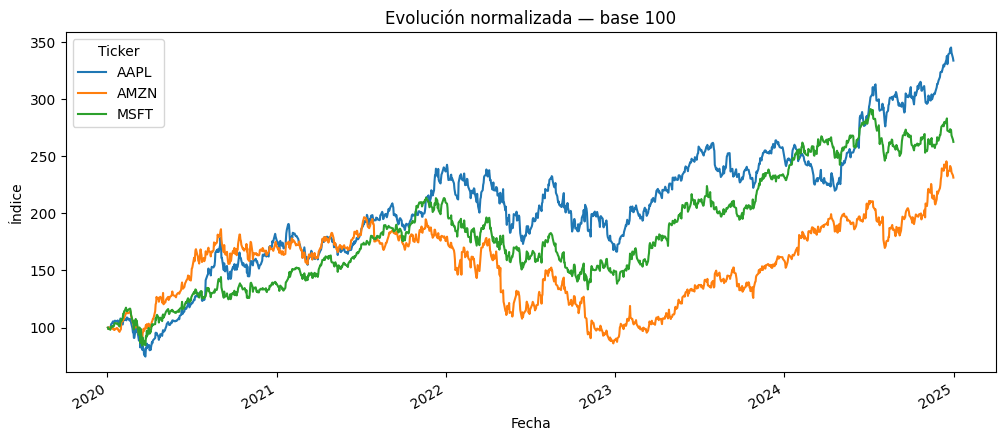

In [46]:
precios_normalizados = precios / precios.iloc[0] * 100

precios_normalizados.plot(figsize=(12, 5))
plt.title("Evolución normalizada — base 100")
plt.xlabel("Fecha")
plt.ylabel("Índice")
plt.show()

# 8. 🔗 Buscar relaciones

En un portafolio no solo importa cómo se comporta cada activo individualmente. También interesa saber cómo se relacionan entre sí.

Primero calculamos los rendimientos de todos los activos.

In [47]:
rendimientos = precios.pct_change()
rendimientos.head()

Ticker,AAPL,AMZN,MSFT
Date,,,
2020-01-02,NaN,NaN,NaN
2020-01-03,-0.009722,-0.012139,-0.012452
2020-01-06,0.007968,0.014886,0.002585
2020-01-07,-0.004703,0.002092,-0.009118
2020-01-08,0.016086,-0.007809,0.015928


In [48]:
correlacion = rendimientos.corr()
correlacion

Ticker,AAPL,AMZN,MSFT
Ticker,,,
AAPL,1.000000,0.591883,0.748121
AMZN,0.591883,1.000000,0.678666
MSFT,0.748121,0.678666,1.000000


### Análisis Financiero de la Matriz de Correlación

La matriz de correlación de los rendimientos es una herramienta fundamental en finanzas para entender la relación entre los movimientos de diferentes activos y es clave para la **diversificación de carteras**.

*   **Correlación Positiva (cercana a +1):** Indica que los rendimientos de los activos tienden a moverse en la misma dirección. Si el rendimiento de un activo sube, es muy probable que el del otro también lo haga, y viceversa. En nuestra matriz, podemos observar una fuerte correlación positiva entre **AAPL y MSFT (0.748)**. Esto significa que si las acciones de Apple suben, las de Microsoft probablemente también lo harán, y si bajan, las de Microsoft también tenderán a bajar. Una correlación alta reduce los beneficios de la diversificación, ya que los activos no actúan como "amortiguadores" el uno del otro en momentos de caída.

*   **Correlación Negativa (cercana a -1):** Sugiere que los rendimientos de los activos tienden a moverse en direcciones opuestas. Si un activo sube, el otro tiende a bajar, y viceversa. Este tipo de correlación es muy deseable para la diversificación, ya que ayuda a mitigar el riesgo de la cartera. En nuestra matriz, no observamos correlaciones negativas fuertes, lo cual es común entre acciones del mismo sector o mercado.

*   **Correlación Cero (cercana a 0):** Implica que no hay una relación lineal predecible entre los movimientos de los rendimientos de los activos. Su comportamiento es independiente el uno del otro. Aunque no reduce el riesgo tan eficazmente como una correlación negativa, sigue siendo beneficioso para la diversificación en comparación con una correlación positiva alta.

#### Implicaciones para la Diversificación:

Para construir un portafolio robusto y diversificado, se busca incluir activos con **baja o negativa correlación**. Esto se debe a que, si un activo experimenta una caída, es probable que otro activo con baja o negativa correlación no caiga (o incluso suba), compensando así parte de la pérdida. Los activos en nuestra matriz muestran correlaciones positivas entre sí, lo que sugiere que son algo dependientes. Por ejemplo, **AAPL** y **AMZN** tienen una correlación de **0.592**, y **AMZN** y **MSFT** de **0.679**. Esto indica que, aunque no se mueven en perfecta sintonía, sus rendimientos sí comparten una tendencia común.

Para mejorar la diversificación, un inversor podría considerar añadir activos de diferentes sectores, geografías o tipos (por ejemplo, bonos, materias primas) que históricamente muestren una correlación más baja o negativa con los activos tecnológicos actuales.

### ¿Cómo podemos leer la correlación?

- Cerca de **1**: los movimientos tienden a ser similares.
- Cerca de **0**: la relación lineal es débil.
- Cerca de **-1**: los movimientos tienden a ser opuestos.

### 💭 Pregunta

Si dos activos presentan una correlación elevada, ¿qué podría significar esto al pensar en diversificación?

# 9. 🚀 Tu análisis

Ahora repite el proceso con los **activos que te fueron asignados**.

Tu análisis debe seguir esta secuencia:

**Obtener → Conocer → Explorar → Transformar → Describir → Comparar → Relacionar → Interpretar**

### Tu misión

1. Obtén los datos históricos desde Yahoo Finance.
2. Explora la estructura del DataFrame.
3. Revisa los datos y los valores faltantes.
4. Observa el comportamiento de los precios.
5. Calcula los rendimientos.
6. Describe los rendimientos con estadísticas.
7. Compara visualmente los activos.
8. Explora la correlación.
9. Escribe una conclusión sustentada en los resultados.

> **Pregunta final:** ¿Qué diferencias encontraste entre los activos y qué información consideras importante conocer antes de incorporarlos a un portafolio?


## 🎫 Salida de aprendizaje

Completa estas tres frases en una celda de texto:

- **Encontré que…**
- **La información que más me ayudó a comparar los activos fue…**
- **Antes de construir un portafolio, considero importante revisar…**


In [49]:
!pip -q install yfinance

In [50]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [51]:
tickers = ["CSCO","C","VLO","ABT","AMZN","MMM"]
precios = yf.download(tickers, start="2025-01-01", end="2026-01-01", auto_adjust=True, progress=False)
precios.shape

(250, 30)

In [52]:
ticker = ["CSCO","C","VLO","ABT","AMZN","MMM"]

datos = yf.download(
    ticker,
    start="2025-01-01",
    end="2026-01-01",
    auto_adjust=False
)

datos.head()

[*********************100%***********************]  6 of 6 completed


Price        Adj Close                                                \
Ticker             ABT        AMZN          C       CSCO         MMM   
Date                                                                   
2025-01-02  109.299225  220.220001  67.039551  56.567001  125.526451   
2025-01-03  109.674988  224.190002  68.055595  56.721184  125.690987   
2025-01-06  108.913826  227.610001  69.723427  56.634457  126.097458   
2025-01-07  109.260681  222.110001  70.624443  56.788647  128.497681   
2025-01-08  110.079651  222.130005  70.221870  57.048836  130.201050   

Price                        Close                                    ...  \
Ticker             VLO         ABT        AMZN          C       CSCO  ...   
Date                                                                  ...   
2025-01-02  117.648293  113.440002  220.220001  69.940002  59.099998  ...   
2025-01-03  118.708710  113.830002  224.190002  71.000000  58.860001  ...   
2025-01-06  116.664314  113.040001  227.610001  72.739998  58.770000  ...   
2025-01-07  118.450768  113.400002  222.110001  73.680000  58.930000  ...   
2025-01-08  119.597160  114.250000  222.130005  73.260002  59.200001  ...   

Price            Open                                      Volume            \
Ticker              C       CSCO         MMM         VLO      ABT      AMZN   
Date                                                                          
2025-01-02  70.940002  59.270000  130.289993  123.300003  3569100  33956600   
2025-01-03  70.879997  58.840000  129.699997  123.199997  4416700  27515600   
2025-01-06  72.230003  58.910000  130.820007  123.970001  6037200  31849800   
2025-01-07  73.900002  58.970001  130.089996  122.570000  5300100  28084200   
2025-01-08  73.449997  58.889999  132.029999  122.199997  4455800  25033300   

Price                                             
Ticker             C      CSCO      MMM      VLO  
Date                                              
2025-01-02   9827400  16144300  3248900  2106800  
2025-01-03  11342900  18859000  2273700  1932500  
2025-01-06  19199700  18543300  3067000  2187500  
2025-01-07  18309400  16863800  3414500  2776200  
2025-01-08  13742800  14400300  4676000  2259000  

[5 rows x 36 columns]

In [53]:
datos.head()

Price        Adj Close                                                \
Ticker             ABT        AMZN          C       CSCO         MMM   
Date                                                                   
2025-01-02  109.299225  220.220001  67.039551  56.567001  125.526451   
2025-01-03  109.674988  224.190002  68.055595  56.721184  125.690987   
2025-01-06  108.913826  227.610001  69.723427  56.634457  126.097458   
2025-01-07  109.260681  222.110001  70.624443  56.788647  128.497681   
2025-01-08  110.079651  222.130005  70.221870  57.048836  130.201050   

Price                        Close                                    ...  \
Ticker             VLO         ABT        AMZN          C       CSCO  ...   
Date                                                                  ...   
2025-01-02  117.648293  113.440002  220.220001  69.940002  59.099998  ...   
2025-01-03  118.708710  113.830002  224.190002  71.000000  58.860001  ...   
2025-01-06  116.664314  113.040001  227.610001  72.739998  58.770000  ...   
2025-01-07  118.450768  113.400002  222.110001  73.680000  58.930000  ...   
2025-01-08  119.597160  114.250000  222.130005  73.260002  59.200001  ...   

Price            Open                                      Volume            \
Ticker              C       CSCO         MMM         VLO      ABT      AMZN   
Date                                                                          
2025-01-02  70.940002  59.270000  130.289993  123.300003  3569100  33956600   
2025-01-03  70.879997  58.840000  129.699997  123.199997  4416700  27515600   
2025-01-06  72.230003  58.910000  130.820007  123.970001  6037200  31849800   
2025-01-07  73.900002  58.970001  130.089996  122.570000  5300100  28084200   
2025-01-08  73.449997  58.889999  132.029999  122.199997  4455800  25033300   

Price                                             
Ticker             C      CSCO      MMM      VLO  
Date                                              
2025-01-02   9827400  16144300  3248900  2106800  
2025-01-03  11342900  18859000  2273700  1932500  
2025-01-06  19199700  18543300  3067000  2187500  
2025-01-07  18309400  16863800  3414500  2776200  
2025-01-08  13742800  14400300  4676000  2259000  

[5 rows x 36 columns]

In [54]:
precios["Close"].head(3)

Ticker,ABT,AMZN,C,CSCO,MMM,VLO
Date,,,,,,
2025-01-02,109.299225,220.220001,67.039551,56.567001,125.526451,117.648293
2025-01-03,109.674988,224.190002,68.055595,56.721184,125.690987,118.708710
2025-01-06,108.913826,227.610001,69.723427,56.634457,126.097458,116.664314


In [55]:
datos.describe()

Price    Adj Close                                                  \
Ticker         ABT        AMZN           C        CSCO         MMM   
count   250.000000  250.000000  250.000000  250.000000  250.000000   
mean    126.183955  217.672800   84.887244   64.692761  148.599973   
std       5.160565   17.096192   14.632969    6.336465   10.269707   
min     107.606361  167.320007   56.105156   51.599434  122.634583   
25%     123.497845  208.022503   73.314178   59.559174  143.513771   
50%     127.222328  222.120003   84.154556   65.406837  148.537018   
75%     129.733089  229.634998   96.713140   67.727060  153.760765   
max     135.810669  254.000000  119.751472   78.791313  170.683029   

Price                    Close                                      ...  \
Ticker         VLO         ABT        AMZN           C        CSCO  ...   
count   250.000000  250.000000  250.000000  250.000000  250.000000  ...   
mean    140.359442  129.465720  217.672800   87.103120   66.461880  ...   
std      20.009970    5.239851   17.096192   14.394888    6.118037  ...   
min     100.829872  111.099998  167.320007   58.130001   53.189999  ...   
25%     127.096783  126.610001  208.022503   75.357500   61.784999  ...   
50%     133.999397  130.599998  222.120003   86.500000   67.064999  ...   
75%     159.199650  133.057499  229.634998   98.302500   69.352503  ...   
max     181.580139  140.220001  254.000000  121.559998   80.250000  ...   

Price         Open                                            Volume  \
Ticker           C        CSCO         MMM         VLO           ABT   
count   250.000000  250.000000  250.000000  250.000000  2.500000e+02   
mean     86.943560   66.461800  151.890360  144.148921  6.523501e+06   
std      14.430514    6.116306    9.940351   19.462791  2.820369e+06   
min      56.160000   53.080002  124.730003  100.900002  1.632200e+06   
25%      75.032499   61.615001  146.439999  131.620003  4.878475e+06   
50%      86.200001   67.009998  152.099998  138.529999  5.758100e+06   
75%      98.384998   69.240002  157.342495  162.477505  7.320025e+06   
max     121.650002   80.239998  172.050003  181.729996  2.756060e+07   

Price                                                                         
Ticker          AMZN             C          CSCO           MMM           VLO  
count   2.500000e+02  2.500000e+02  2.500000e+02  2.500000e+02  2.500000e+02  
mean    4.443937e+07  1.479825e+07  2.096021e+07  3.474976e+06  3.068196e+06  
std     1.992730e+07  6.566856e+06  9.715764e+06  1.550286e+06  1.250631e+06  
min     1.142050e+07  5.865200e+06  7.320900e+06  8.544000e+05  8.816000e+05  
25%     3.242772e+07  1.092725e+07  1.552375e+07  2.459000e+06  2.254500e+06  
50%     3.935265e+07  1.319205e+07  1.801770e+07  3.029950e+06  2.821400e+06  
75%     4.977510e+07  1.669170e+07  2.275278e+07  4.117750e+06  3.520750e+06  
max     1.663408e+08  5.173050e+07  8.488190e+07  1.170190e+07  9.514600e+06  

[8 rows x 36 columns]

In [56]:
datos.isna().sum()

Price      Ticker
Adj Close  ABT       0
           AMZN      0
           C         0
           CSCO      0
           MMM       0
           VLO       0
Close      ABT       0
           AMZN      0
           C         0
           CSCO      0
           MMM       0
           VLO       0
High       ABT       0
           AMZN      0
           C         0
           CSCO      0
           MMM       0
           VLO       0
Low        ABT       0
           AMZN      0
           C         0
           CSCO      0
           MMM       0
           VLO       0
Open       ABT       0
           AMZN      0
           C         0
           CSCO      0
           MMM       0
           VLO       0
Volume     ABT       0
           AMZN      0
           C         0
           CSCO      0
           MMM       0
           VLO       0
dtype: int64

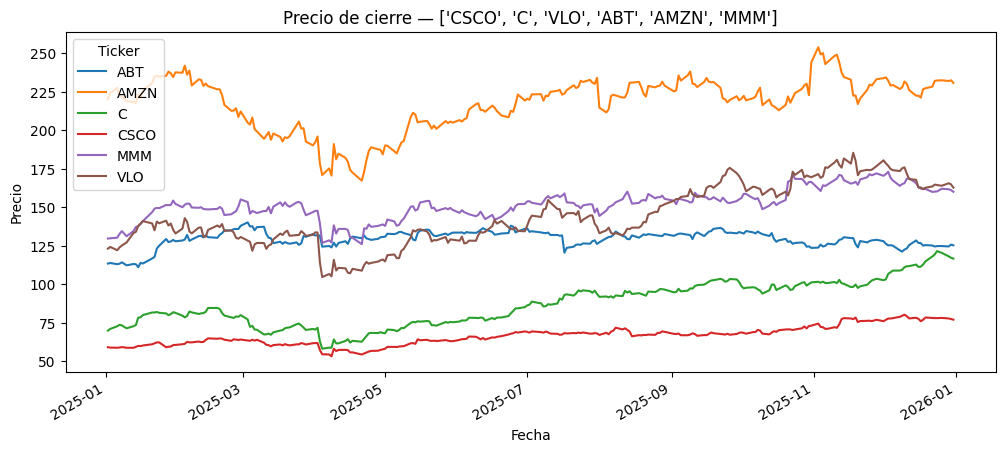

In [57]:
cierre = datos["Close"]

cierre.plot(figsize=(12, 5))
plt.title(f"Precio de cierre — {ticker}")
plt.xlabel("Fecha")
plt.ylabel("Precio")
plt.show()

In [58]:
rendimiento = cierre.pct_change()
rendimiento.head()

Ticker,ABT,AMZN,C,CSCO,MMM,VLO
Date,,,,,,
2025-01-02,NaN,NaN,NaN,NaN,NaN,NaN
2025-01-03,0.003438,0.018027,0.015156,-0.004061,0.001311,0.009013
2025-01-06,-0.006940,0.015255,0.024507,-0.001529,0.003234,-0.017222
2025-01-07,0.003185,-0.024164,0.012923,0.002722,0.019035,0.015313
2025-01-08,0.007496,0.000090,-0.005700,0.004582,0.013256,0.009678


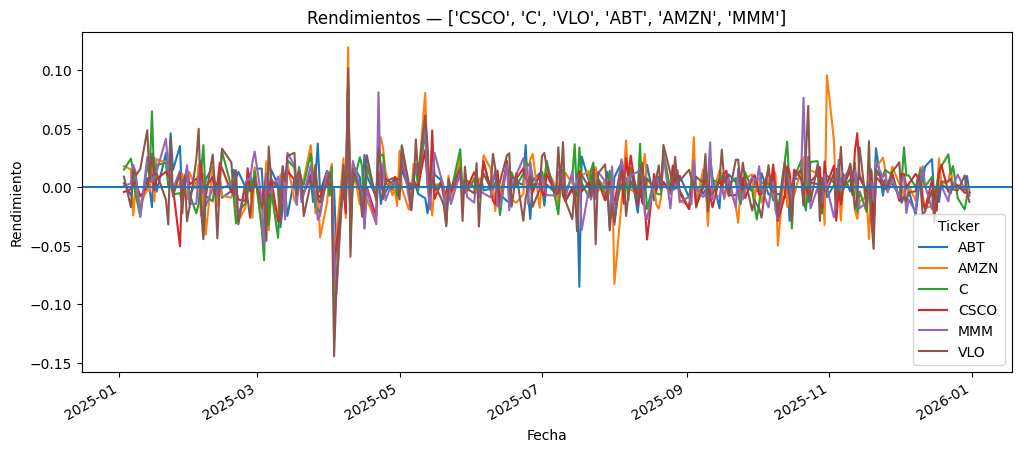

In [59]:
rendimiento.plot(figsize=(12, 5))

plt.axhline(0)
plt.title(f"Rendimientos — {ticker}")
plt.xlabel("Fecha")
plt.ylabel("Rendimiento")
plt.show()

In [60]:
rendimiento.describe()

Ticker,ABT,AMZN,C,CSCO,MMM,VLO
count,249.000000,249.000000,249.000000,249.000000,249.000000,249.000000
mean,0.000498,0.000422,0.002257,0.001178,0.001020,0.001403
std,0.014033,0.021726,0.019858,0.015091,0.018733,0.023639
min,-0.085244,-0.089791,-0.121377,-0.072954,-0.091813,-0.144664
25%,-0.005672,-0.011164,-0.006251,-0.005271,-0.009009,-0.010388
50%,0.000990,0.000602,0.003534,0.001005,0.001547,0.002582
75%,0.007546,0.012418,0.012487,0.009914,0.010666,0.013966
max,0.046188,0.119770,0.091543,0.092875,0.087763,0.101921


In [61]:
print("Percentil 1:", rendimiento.quantile(0.01))
print("Percentil 5:", rendimiento.quantile(0.05))

Percentil 1: Ticker
ABT    -0.032008
AMZN   -0.050849
C      -0.053257
CSCO   -0.046605
MMM    -0.044189
VLO    -0.056226
Name: 0.01, dtype: float64
Percentil 5: Ticker
ABT    -0.019416
AMZN   -0.030548
C      -0.024795
CSCO   -0.021433
MMM    -0.027379
VLO    -0.031785
Name: 0.05, dtype: float64


In [62]:
print("Promedio:", rendimiento.mean())
print("Desviación estándar:", rendimiento.std())
print("Mínimo:", rendimiento.min())
print("Máximo:", rendimiento.max())

Promedio: Ticker
ABT     0.000498
AMZN    0.000422
C       0.002257
CSCO    0.001178
MMM     0.001020
VLO     0.001403
dtype: float64
Desviación estándar: Ticker
ABT     0.014033
AMZN    0.021726
C       0.019858
CSCO    0.015091
MMM     0.018733
VLO     0.023639
dtype: float64
Mínimo: Ticker
ABT    -0.085244
AMZN   -0.089791
C      -0.121377
CSCO   -0.072954
MMM    -0.091813
VLO    -0.144664
dtype: float64
Máximo: Ticker
ABT     0.046188
AMZN    0.119770
C       0.091543
CSCO    0.092875
MMM     0.087763
VLO     0.101921
dtype: float64


In [63]:
activos = ["CSCO","C","VLO","ABT","AMZN","MMM"]

datos = yf.download(
    activos,
    start="2025-01-01",
    end="2026-01-01",
    auto_adjust=False
)

precios = datos["Close"]
precios.head()

[*********************100%***********************]  6 of 6 completed


Ticker,ABT,AMZN,C,CSCO,MMM,VLO
Date,,,,,,
2025-01-02,113.440002,220.220001,69.940002,59.099998,129.699997,123.150002
2025-01-03,113.830002,224.190002,71.000000,58.860001,129.869995,124.260002
2025-01-06,113.040001,227.610001,72.739998,58.770000,130.289993,122.120003
2025-01-07,113.400002,222.110001,73.680000,58.930000,132.770004,123.989998
2025-01-08,114.250000,222.130005,73.260002,59.200001,134.529999,125.190002


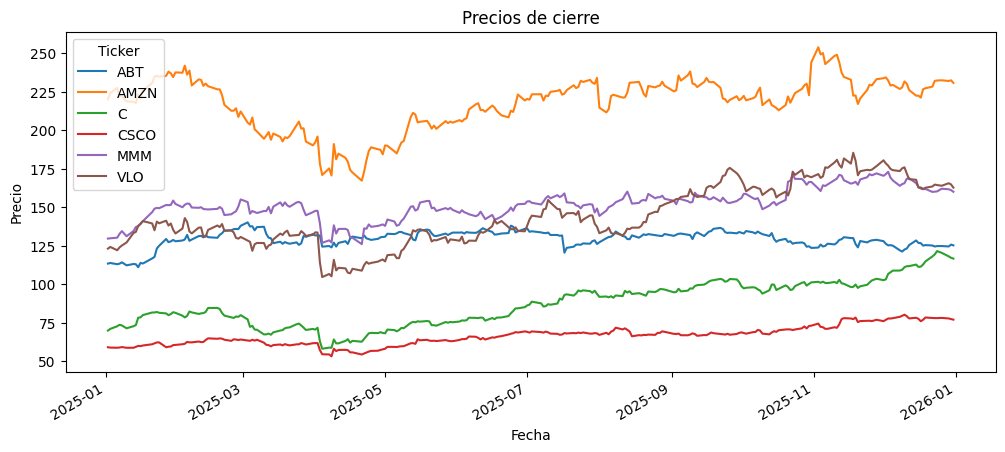

In [64]:
precios.plot(figsize=(12, 5))

plt.title("Precios de cierre")
plt.xlabel("Fecha")
plt.ylabel("Precio")
plt.show()

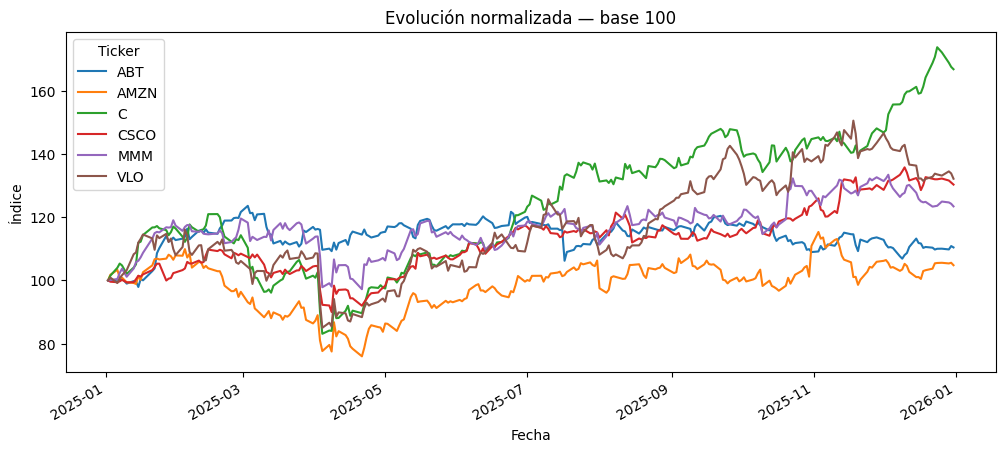

In [65]:
precios_normalizados = precios / precios.iloc[0] * 100

precios_normalizados.plot(figsize=(12, 5))
plt.title("Evolución normalizada — base 100")
plt.xlabel("Fecha")
plt.ylabel("Índice")
plt.show()

In [66]:
rendimientos = precios.pct_change()
rendimientos.head()

Ticker,ABT,AMZN,C,CSCO,MMM,VLO
Date,,,,,,
2025-01-02,NaN,NaN,NaN,NaN,NaN,NaN
2025-01-03,0.003438,0.018027,0.015156,-0.004061,0.001311,0.009013
2025-01-06,-0.006940,0.015255,0.024507,-0.001529,0.003234,-0.017222
2025-01-07,0.003185,-0.024164,0.012923,0.002722,0.019035,0.015313
2025-01-08,0.007496,0.000090,-0.005700,0.004582,0.013256,0.009678


In [67]:
correlacion = rendimientos.corr()
correlacion

Ticker,ABT,AMZN,C,CSCO,MMM,VLO
Ticker,,,,,,
ABT,1.000000,-0.004932,0.113230,0.161989,0.191121,0.171891
AMZN,-0.004932,1.000000,0.564323,0.459221,0.487251,0.370831
C,0.113230,0.564323,1.000000,0.598200,0.557016,0.462794
CSCO,0.161989,0.459221,0.598200,1.000000,0.480565,0.376431
MMM,0.191121,0.487251,0.557016,0.480565,1.000000,0.441969
VLO,0.171891,0.370831,0.462794,0.376431,0.441969,1.000000
